In [2]:
import torch

In [3]:
#check torch version
print("your torch version is",torch.__version__)

your torch version is 2.5.1


In [4]:
#check cuda availibilty now

print(f"Torch version",torch.__version__)
print(f"CUDA Available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"CUDA version:{torch.version.cuda}")
    print(f"GPU Device: {torch.cuda.get_device_name(0)}")

Torch version 2.5.1
CUDA Available: True
CUDA version:12.1
GPU Device: NVIDIA GeForce RTX 3050 6GB Laptop GPU


Image loaded Successfully
Format:None, Size:(512, 512),Mode:RGB


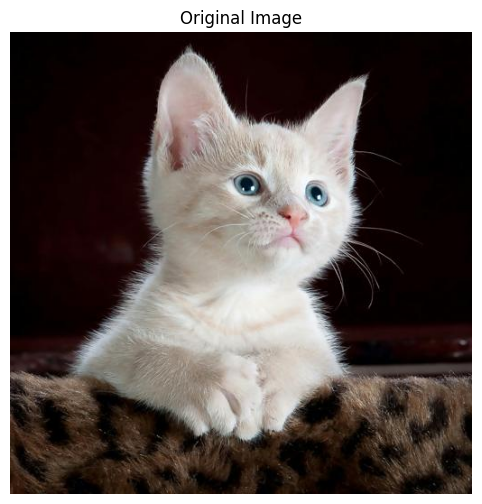

In [5]:
#Use PIL library and then display it using matpotlib

import os
from PIL import Image
import matplotlib.pyplot as plt
import torchvision.transforms as T

path_of_image=r"D:\MY DS-projects\vision-language-models\VLM-Transformers\src\data\images\image.png"

#check if file exists and load it
try:
    if os.path.exists(path_of_image):
        img=Image.open(path_of_image).convert("RGB")

    #Display image results
        print(f"Image loaded Successfully")
        print(f"Format:{img.format}, Size:{img.size},Mode:{img.mode}")
        plt.figure(figsize=(8,6))
        plt.imshow(img)
        plt.title("Original Image")
        plt.axis('off')
        plt.show()
except Exception as e:
    print(f"Image not loaded successfully")


Tensor shape: torch.Size([3, 224, 224])


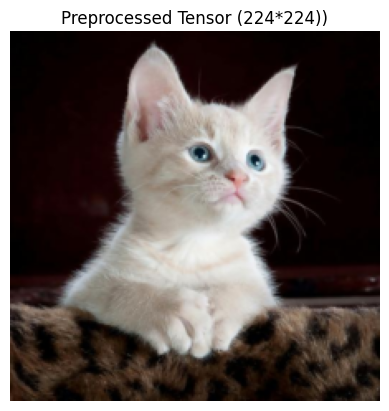

In [7]:
# Simple transformation pipeline
transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
])

img_tensor=transform(img)

print(f"Tensor shape: {img_tensor.shape}")

#Display the preprocessed tensor

plt.imshow(img_tensor.permute(1,2,0))
plt.title("Preprocessed Tensor (224*224))")
plt.axis('off')
plt.show()

Divided 224x224 image into 49 patches of size 32x32


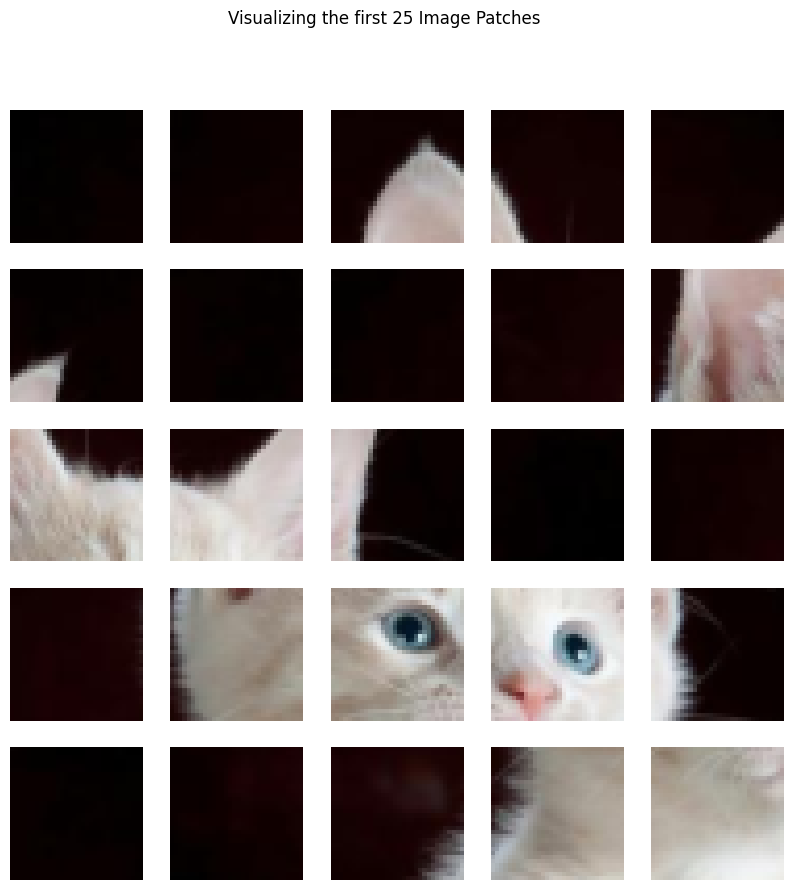

In [8]:
"""
Let's implement the Image Patching logic.In a Vision Transformer (the "Eyes" of your VLM), the model doesn't look at the whole image at once. Instead, it breaks the image into a grid of small squares (patches), treats each square as a "word
"""
import torch
import torch.nn.functional as F

def create_patch_grid(img_tensor, patch_size=16):
    """
    Divides an image tensor into patches and displays them.
    img_tensor: (3, H, W)
    """
    c, h, w = img_tensor.shape
    
    
    patches = img_tensor.unfold(1, patch_size, patch_size) 
    patches = patches.unfold(2, patch_size, patch_size)
    
    patches = patches.permute(1, 2, 0, 3, 4).reshape(-1, c, patch_size, patch_size)
    
    print(f"Divided {h}x{w} image into {patches.shape[0]} patches of size {patch_size}x{patch_size}")
    return patches

# Create patches
patches = create_patch_grid(img_tensor, patch_size=32) # Using 32 for better visibility

# Visualize the first 25 patches in a grid
plt.figure(figsize=(10, 10))
for i in range(min(25, patches.shape[0])):
    plt.subplot(5, 5, i + 1)
    # Convert tensor back to image for plotting
    patch_img = patches[i].permute(1, 2, 0).numpy()
    plt.imshow(patch_img)
    plt.axis('off')
plt.suptitle("Visualizing the first 25 Image Patches")
plt.show()



In [9]:
"""

Now we are building the first "Neural" part of VLM.

In a standard Vision Transformer (ViT), we don't manually slice the image. Instead, we use a 2D Convolutional Layer to do two things at once:

Divide the image into patches.
Project those patches into a high-dimensional vector space (the "Embedding" space).

"""

import torch.nn as nn

class PatchEmbedding(nn.Module):
    """
    Turns an image into a sequence of learnable patch of embeddings
    """
    def __init__(self,img_size=224, patch_size=16, in_channels=3, embed_dimension=768):
            super().__init__()
            self.img_size=img_size
            self.patch_size=patch_size
            self.n_patches=(img_size // patch_size) ** 2

        # This Conv layer does the patching and projection in one step
        # Kernel size = Patch size
        # Stride = Patch size (so patches don't overlap)

            self.projection=nn.Conv2d(
                in_channels,
                embed_dimension,
                kernel_size=patch_size,
                stride=patch_size
            )
    def forward(self,x):
         # x shape: (Batch, Channels, Height, Width) -> [B, 3, 224, 224]
        x = self.projection(x) 
        # Output shape: (Batch, Embed_Dim, Grid_H, Grid_W) -> [B, 768, 14, 14]
        
        x = x.flatten(2) 
        # Output shape: (Batch, Embed_Dim, Num_Patches) -> [B, 768, 196]
        
        x = x.transpose(1, 2) 
        # Final shape: (Batch, Num_Patches, Embed_Dim) -> [B, 196, 768]
        return x

        # --- Test the Layer ---
# 1. Initialize the layer
# 768 is the standard embedding size for a "ViT-Base" model
patch_embed = PatchEmbedding(img_size=224, patch_size=16, embed_dimension=768)
# 2. Add a 'Batch' dimension to our image tensor (B, C, H, W)
input_tensor = img_tensor.unsqueeze(0) 
# 3. Pass through the layer
embedded_patches = patch_embed(input_tensor)
print(f"Input shape: {input_tensor.shape}")
print(f"Number of patches: {patch_embed.n_patches}")
print(f"Final Embedding shape: {embedded_patches.shape}") 
# Expected: [1, 196, 768]


Input shape: torch.Size([1, 3, 224, 224])
Number of patches: 196
Final Embedding shape: torch.Size([1, 196, 768])


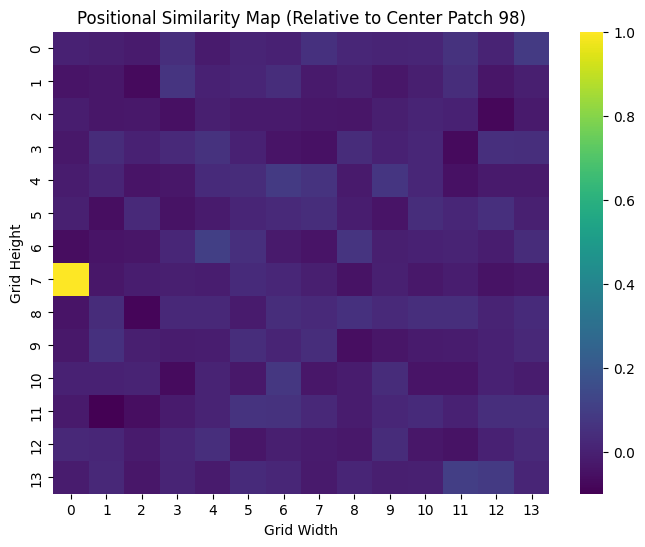

Heatmap Interpretation: The bright spot shows that the model 'knows' where the patch is.
Nearby patches have higher similarity (yellow/green), proving spatial awareness!!


In [17]:
"""
Since we can't "see" high-dimensional numbers easily, the best way to visualize Positional Encodings is to look at a Similarity Heatmap.

This will prove that the model "knows" that a patch in the top-left corner is more related to its neighbors than to a patch in the bottom-right.

"""

import torch.nn as nn
import seaborn as sns # For a nice heatmap

class VisionInput(nn.Module):
    def __init__(self, img_size=224, patch_size=16, embed_dim=768):
        super().__init__()
        self.patch_embed = PatchEmbedding(img_size, patch_size, 3, embed_dim)
        
        # 1. Create a Learnable Parameter for positions
        # Shape: (1, Num_Patches, Embed_Dim)
        num_patches = self.patch_embed.n_patches
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches, embed_dim))
        
        # Initialize with small random numbers
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

    def forward(self, x):
        x = self.patch_embed(x)
        # 2. Add the positional information to the patches
        x = x + self.pos_embed
        return x


# Initialize our module
vision_input = VisionInput()
pos_data = vision_input.pos_embed.detach().squeeze(0) # Get the embeddings [196, 768]

# Calculate Similarity: How similar is one patch to all others?
# We'll pick the middle patch (index 98 for a 14x14 grid)
target_patch_idx = 98 
target_vector = pos_data[target_patch_idx].unsqueeze(0)
# Compute Cosine Similarity
sim = torch.cosine_similarity(target_vector, pos_data, dim=1)
sim_grid = sim.reshape(14, 14) # Back to a square grid

# Plot the Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(sim_grid.numpy(), annot=False, cmap="viridis")
plt.title(f"Positional Similarity Map (Relative to Center Patch {target_patch_idx})")
plt.xlabel("Grid Width")
plt.ylabel("Grid Height")
plt.show()

print("Heatmap Interpretation: The bright spot shows that the model 'knows' where the patch is.")
print("Nearby patches have higher similarity (yellow/green), proving spatial awareness!!")
